# Information Theory for Machine Learning

## Why Information Theory?

Information theory, founded by Claude Shannon in 1948, quantifies **how much information** is in data. It is deeply embedded in ML:
- **Cross-entropy loss** (classification training objective) = negative log-likelihood = comes from information theory
- **Decision trees** split on **information gain**
- **VAEs** minimize KL divergence
- **GANs** minimize Jensen-Shannon divergence
- **Mutual information** measures feature relevance

---

## Table of Contents
1. Self-Information (Surprisal)
2. Entropy
3. Joint and Conditional Entropy
4. Mutual Information
5. KL Divergence
6. Cross-Entropy
7. Jensen-Shannon Divergence
8. Information Gain
9. Bits vs Nats
10. Applications in ML

## 1. Self-Information (Surprisal)

The **information content** (surprisal) of event $x$ with probability $p(x)$:
$$I(x) = -\log p(x)$$

**Intuition:**
- Rare events (small $p$) carry more information
- Certain events ($p=1$) carry zero information
- Independent events: $I(x,y) = I(x) + I(y)$ (information is additive)

**Example:** Flipping a fair coin heads has probability 0.5.
$$I(\text{heads}) = -\log_2(0.5) = 1 \text{ bit}$$

Rolling a fair die any face has probability 1/6:
$$I(\text{face}=3) = -\log_2(1/6) \approx 2.585 \text{ bits}$$

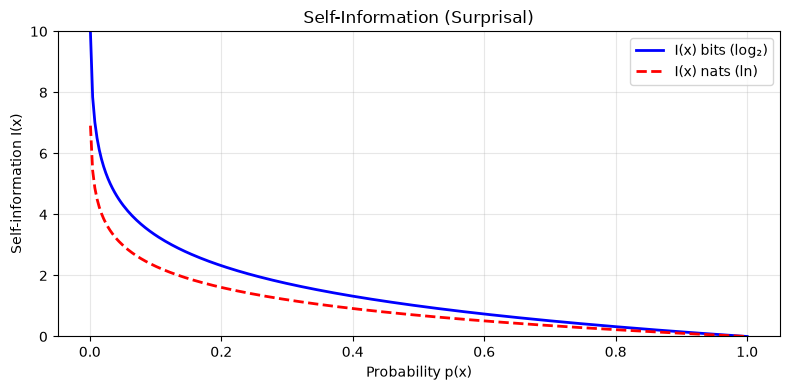

Fair coin heads: p=0.5000, I=1.000 bits
Fair die (any face): p=0.1667, I=2.585 bits
Rare event (1%): p=0.0100, I=6.644 bits
Very rare (0.1%): p=0.0010, I=9.966 bits


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Self-information
p = np.linspace(0.001, 1, 300)
I_bits = -np.log2(p)
I_nats = -np.log(p)  # natural log

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p, I_bits, 'b-', linewidth=2, label='I(x) bits (log₂)')
ax.plot(p, I_nats, 'r--', linewidth=2, label='I(x) nats (ln)')
ax.set_xlabel('Probability p(x)')
ax.set_ylabel('Self-information I(x)')
ax.set_title('Self-Information (Surprisal)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10)
plt.tight_layout()
plt.show()

# Examples
events = {'Fair coin heads': 0.5, 'Fair die (any face)': 1/6, 
          'Rare event (1%)': 0.01, 'Very rare (0.1%)': 0.001}

for event, prob in events.items():
    print(f"{event}: p={prob:.4f}, I={-np.log2(prob):.3f} bits")

## 2. Entropy

**Shannon Entropy** is the expected self-information the average uncertainty of a random variable:

$$H(X) = -\sum_{x \in \mathcal{X}} p(x) \log p(x) = \mathbb{E}[-\log p(X)]$$

For continuous distributions (differential entropy):
$$h(X) = -\int_{-\infty}^\infty f(x) \log f(x)\, dx$$

### Properties
- $H(X) \geq 0$ always (with equality iff $X$ is deterministic)
- **Maximum entropy:** Uniform distribution maximizes entropy: $H \leq \log |\mathcal{X}|$
- $H(X) = \log n$ for uniform over $n$ outcomes

### Binary Entropy
For a Bernoulli($p$) variable:
$$H_b(p) = -p\log p - (1-p)\log(1-p)$$

Maximum at $p=0.5$: $H_b(0.5) = 1$ bit.

**Intuition:** Entropy measures uncertainty. A fair coin (max uncertainty) has entropy 1 bit. A biased coin ($p=0.99$) has very low entropy we're almost certain what will happen.

Uniform: H = 2.5850 bits
Slightly skewed: H = 2.4710 bits
Very skewed: H = 1.5568 bits
Deterministic: H = -0.0000 bits


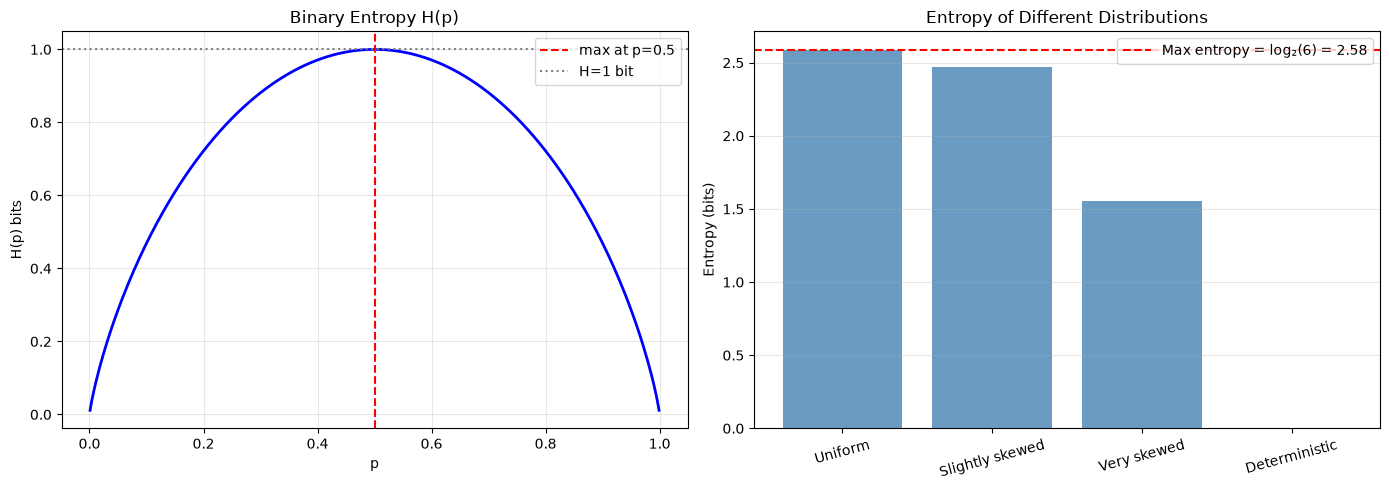

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy

def entropy(probs, base=2):
    probs = np.array(probs, dtype=float)
    probs = probs[probs > 0]  # avoid log(0)
    return -np.sum(probs * np.log(probs) / np.log(base))

# Binary entropy
p = np.linspace(0.001, 0.999, 300)
H_binary = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p, H_binary, 'b-', linewidth=2)
axes[0].axvline(0.5, color='r', linestyle='--', label='max at p=0.5')
axes[0].axhline(1.0, color='gray', linestyle=':', label='H=1 bit')
axes[0].set_title('Binary Entropy H(p)')
axes[0].set_xlabel('p')
axes[0].set_ylabel('H(p) bits')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Entropy vs distribution type
n = 6  # number of outcomes
distributions = {
    'Uniform': [1/n]*n,
    'Slightly skewed': [0.3, 0.2, 0.15, 0.15, 0.1, 0.1],
    'Very skewed': [0.7, 0.1, 0.05, 0.05, 0.05, 0.05],
    'Deterministic': [1.0, 0, 0, 0, 0, 0],
}

names, entropies = [], []
for name, dist in distributions.items():
    h = entropy(dist)
    names.append(name)
    entropies.append(h)
    print(f"{name}: H = {h:.4f} bits")

axes[1].bar(names, entropies, color='steelblue', alpha=0.8)
axes[1].axhline(np.log2(n), color='red', linestyle='--', label=f'Max entropy = log₂({n}) = {np.log2(n):.2f}')
axes[1].set_title('Entropy of Different Distributions')
axes[1].set_ylabel('Entropy (bits)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Joint and Conditional Entropy

### Joint Entropy
$$H(X, Y) = -\sum_{x,y} p(x,y) \log p(x,y)$$

If $X,Y$ are independent: $H(X,Y) = H(X) + H(Y)$

In general: $H(X,Y) \leq H(X) + H(Y)$ (subadditivity)

### Conditional Entropy
$$H(Y \mid X) = -\sum_{x,y} p(x,y) \log p(y \mid x) = H(X,Y) - H(X)$$

**Chain rule:** $H(X,Y) = H(X) + H(Y \mid X)$

**Conditioning never increases entropy:** $H(Y \mid X) \leq H(Y)$

## 4. Mutual Information

**Mutual information** measures how much knowing $X$ tells us about $Y$:
$$I(X; Y) = H(Y) - H(Y \mid X) = H(X) + H(Y) - H(X, Y)$$

Equivalently:
$$I(X; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)} = D_{KL}(p(X,Y) \| p(X)p(Y))$$

### Properties
- $I(X;Y) \geq 0$ always
- $I(X;Y) = 0$ iff $X$ and $Y$ are independent
- $I(X;Y) = I(Y;X)$ (symmetric)
- $I(X;X) = H(X)$ (self-information = entropy)

**In ML:**
- Feature selection: select features with high $I(\text{feature}; \text{label})$
- Information bottleneck method: compress representations while preserving mutual information with labels
- Contrastive learning (SimCLR, MoCo): maximize MI between augmented views

## 5. KL Divergence

**Kullback-Leibler (KL) divergence** measures how distribution $P$ differs from reference distribution $Q$:

$$D_{KL}(P \| Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)} = \mathbb{E}_P\left[\log \frac{P(X)}{Q(X)}\right]$$

For continuous distributions:
$$D_{KL}(P \| Q) = \int p(x) \log \frac{p(x)}{q(x)}\, dx$$

### Properties
- $D_{KL}(P \| Q) \geq 0$ always (**Gibbs' inequality**)
- $D_{KL}(P \| Q) = 0$ iff $P = Q$ almost everywhere
- **NOT symmetric:** $D_{KL}(P\|Q) \neq D_{KL}(Q\|P)$ in general
- **NOT a metric** (no triangle inequality)

### KL for Two Gaussians
$$D_{KL}(\mathcal{N}(\mu_1,\sigma_1^2) \| \mathcal{N}(\mu_2,\sigma_2^2)) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$$

### VAE KL term (latent space regularization)
$$D_{KL}(\mathcal{N}(\mu,\sigma^2) \| \mathcal{N}(0,I)) = \frac{1}{2}\sum_j \left(\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1\right)$$

**In ML:**
- VAE objective: $\mathcal{L} = \mathbb{E}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$
- Policy optimization (TRPO, PPO): KL constraint on policy updates
- Knowledge distillation: minimize KL between student and teacher distributions

KL(P||Q) = 0.1064 nats
KL(Q||P) = 0.1218 nats (asymmetric!)

KL(N(1,1) || N(0,1)) = 0.5000
KL(N(0,1) || N(0,1)) = 0.0000 (same dist)
KL(N(0,2) || N(0,1)) = 0.8069


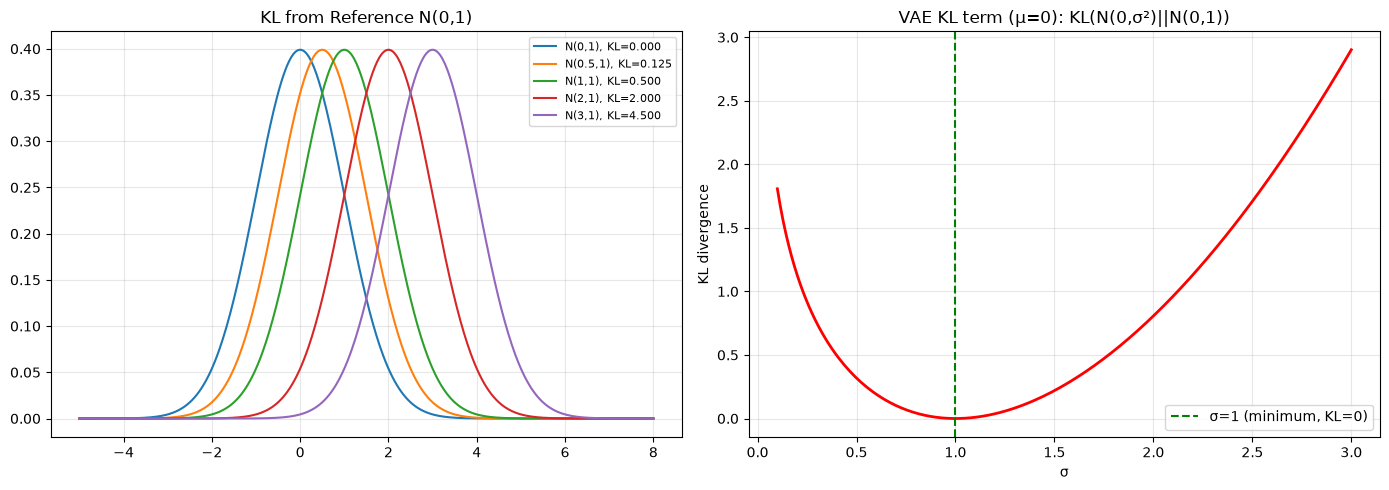

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import rel_entr

def kl_divergence_discrete(P, Q, eps=1e-10):
    P, Q = np.array(P, dtype=float), np.array(Q, dtype=float)
    P += eps; Q += eps
    P /= P.sum(); Q /= Q.sum()
    return np.sum(P * np.log(P / Q))

def kl_gaussian(mu1, sigma1, mu2, sigma2):
    return (np.log(sigma2/sigma1) + 
            (sigma1**2 + (mu1-mu2)**2) / (2*sigma2**2) - 0.5)

# Discrete example
P = [0.4, 0.3, 0.2, 0.1]
Q = [0.25, 0.25, 0.25, 0.25]  # uniform
print(f"KL(P||Q) = {kl_divergence_discrete(P, Q):.4f} nats")
print(f"KL(Q||P) = {kl_divergence_discrete(Q, P):.4f} nats (asymmetric!)")

# Gaussian KL divergence
print(f"\nKL(N(1,1) || N(0,1)) = {kl_gaussian(1, 1, 0, 1):.4f}")
print(f"KL(N(0,1) || N(0,1)) = {kl_gaussian(0, 1, 0, 1):.4f} (same dist)")
print(f"KL(N(0,2) || N(0,1)) = {kl_gaussian(0, 2, 0, 1):.4f}")

# Visualize KL between two Gaussians
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(-5, 8, 500)
mus = [0, 0.5, 1, 2, 3]
kls = [kl_gaussian(mu, 1, 0, 1) for mu in mus]

for mu, kl in zip(mus, kls):
    axes[0].plot(x, norm.pdf(x, mu, 1), label=f'N({mu},1), KL={kl:.3f}')
axes[0].set_title('KL from Reference N(0,1)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# VAE KL term visualization
sigma_range = np.linspace(0.1, 3, 200)
# For mu=0: KL = 0.5*(sigma^2 - log(sigma^2) - 1)
kl_vae = 0.5 * (sigma_range**2 - np.log(sigma_range**2) - 1)
axes[1].plot(sigma_range, kl_vae, 'r-', linewidth=2)
axes[1].axvline(1.0, color='green', linestyle='--', label='σ=1 (minimum, KL=0)')
axes[1].set_title('VAE KL term (μ=0): KL(N(0,σ²)||N(0,1))')
axes[1].set_xlabel('σ')
axes[1].set_ylabel('KL divergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Cross-Entropy

**Cross-entropy** measures the average code length when using distribution $Q$ to encode data from $P$:
$$H(P, Q) = -\sum_x P(x) \log Q(x) = H(P) + D_{KL}(P \| Q)$$

### Relationship
$$D_{KL}(P \| Q) = H(P, Q) - H(P)$$

Since $H(P)$ is fixed for a given dataset, **minimizing cross-entropy = minimizing KL divergence**.

### Cross-Entropy Loss in ML
For multi-class classification with $K$ classes:
$$\mathcal{L}_{CE} = -\sum_{i=1}^n \sum_{k=1}^K y_{ik} \log \hat{y}_{ik}$$

For binary classification:
$$\mathcal{L}_{BCE} = -\frac{1}{n}\sum_{i=1}^n \left[y_i \log \hat{y}_i + (1-y_i) \log(1-\hat{y}_i)\right]$$

**This is the standard loss function for classification!** Minimizing it makes the predicted distribution $Q = \hat{y}$ as close as possible to the true distribution $P = y$.

In [4]:
import numpy as np

def cross_entropy(P, Q, eps=1e-10):
    P, Q = np.array(P), np.array(Q)
    Q = np.clip(Q, eps, 1)
    return -np.sum(P * np.log(Q))

def softmax(x):
    e = np.exp(x - x.max())
    return e / e.sum()

# Perfect prediction
y_true = [1, 0, 0]  # class 0
y_perfect = [0.99, 0.005, 0.005]
y_wrong = [0.1, 0.8, 0.1]

print(f"Cross-entropy (perfect): {cross_entropy(y_true, y_perfect):.4f}")
print(f"Cross-entropy (wrong):   {cross_entropy(y_true, y_wrong):.4f}")

# Binary cross-entropy for sigmoid output
def bce(y_true, y_pred, eps=1e-10):
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

y = np.array([1, 0, 1, 1, 0])
p_good = np.array([0.9, 0.1, 0.8, 0.95, 0.05])
p_bad = np.array([0.6, 0.4, 0.55, 0.65, 0.45])

print(f"\nBCE (good predictions):  {bce(y, p_good):.4f}")
print(f"BCE (bad predictions):   {bce(y, p_bad):.4f}")

# In PyTorch terms:
try:
    import torch
    import torch.nn as nn
    
    logits = torch.tensor([[2.0, 0.5, -1.0]])
    target = torch.tensor([0])  # class 0
    
    ce_loss = nn.CrossEntropyLoss()
    loss = ce_loss(logits, target)
    print(f"\nPyTorch CrossEntropyLoss: {loss.item():.4f}")
    print(f"Manual: {cross_entropy([1,0,0], softmax(logits[0].numpy())):.4f}")
except ImportError:
    # Manual equivalent
    logits = np.array([2.0, 0.5, -1.0])
    probs = softmax(logits)
    target = 0
    loss = -np.log(probs[target])
    print(f"\nManual CE loss (class 0): {loss:.4f}")
    print(f"Softmax probabilities: {probs.round(4)}")

Cross-entropy (perfect): 0.0101
Cross-entropy (wrong):   2.3026

BCE (good predictions):  0.1073
BCE (bad predictions):   0.5296



PyTorch CrossEntropyLoss: 0.2413
Manual: 0.2413


## 7. Jensen-Shannon Divergence

A **symmetric, bounded** alternative to KL divergence:
$$JSD(P \| Q) = \frac{1}{2} D_{KL}(P \| M) + \frac{1}{2} D_{KL}(Q \| M), \quad M = \frac{P+Q}{2}$$

**Properties:**
- $0 \leq JSD(P\|Q) \leq 1$ (with log base 2)
- Symmetric: $JSD(P\|Q) = JSD(Q\|P)$
- $JSD(P\|Q) = 0$ iff $P = Q$
- $\sqrt{JSD}$ is a proper metric

**In GANs (original):** The original GAN objective minimizes JSD between the real data distribution $p_{data}$ and the generator distribution $p_g$:
$$\min_G \max_D V(D,G) = \mathbb{E}_{x\sim p_{data}}[\log D(x)] + \mathbb{E}_{z\sim p_z}[\log(1-D(G(z)))]$$
Optimal solution: $V^* = 2 \cdot JSD(p_{data} \| p_g) - \log 4$

## 8. Information Gain

Used in **decision trees** to select the best feature to split on.

$$IG(Y, X) = H(Y) - H(Y \mid X) = I(X; Y)$$

The information gain of splitting on feature $X$ for target $Y$ = reduction in entropy of $Y$ after knowing $X$.

### Gini Impurity (alternative to entropy)
$$\text{Gini}(p) = 1 - \sum_k p_k^2 = \sum_{k \neq k'} p_k p_{k'}$$

Both entropy and Gini measure node impurity. Entropy is slightly smoother.

### Mutual Information for Feature Selection
$$\text{MI}(X_i; Y) = H(Y) - H(Y \mid X_i)$$

Select features with highest MI with the target label.

In [5]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

def entropy(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-10))

def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

def information_gain(y, mask):
    y_left, y_right = y[mask], y[~mask]
    n, n_l, n_r = len(y), len(y_left), len(y_right)
    return entropy(y) - (n_l/n * entropy(y_left) + n_r/n * entropy(y_right))

# Iris dataset feature importance via MI
iris = load_iris()
X, y = iris.data, iris.target

mi_scores = mutual_info_classif(X, y, random_state=42)

print("Mutual Information scores (feature relevance to target):")
for name, mi in zip(iris.feature_names, mi_scores):
    print(f"  {name:30s}: MI = {mi:.4f}")

print(f"\nTotal entropy of target: {entropy(y):.4f} bits")

# Decision tree split example
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

clf = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42)
clf.fit(X, y)
print(f"\nDecision tree uses feature: {iris.feature_names[clf.tree_.feature[0]]} for root split")
print(f"Split threshold: {clf.tree_.threshold[0]:.3f}")

Mutual Information scores (feature relevance to target):
  sepal length (cm)             : MI = 0.5114
  sepal width (cm)              : MI = 0.2994
  petal length (cm)             : MI = 0.9926
  petal width (cm)              : MI = 0.9856

Total entropy of target: 1.5850 bits

Decision tree uses feature: petal length (cm) for root split
Split threshold: 2.450


## 9. Bits vs Nats

The choice of logarithm base determines the unit of information:

| Base | Unit | Common Use |
|------|------|------------|
| $\log_2$ | **bits** | Information theory, data compression |
| $\ln$ (natural) | **nats** | ML/statistics (mathematical convenience) |
| $\log_{10}$ | **bans** (Hartley) | Rare |

**Conversion:** $1 \text{ bit} = \ln(2) \approx 0.693 \text{ nats}$

In ML, **nats** are used (natural log) because derivatives are cleaner: $\frac{d}{dx}\ln(x) = \frac{1}{x}$.

PyTorch `nn.CrossEntropyLoss` outputs in **nats** (uses `torch.log`).

## 10. Applications in Machine Learning

### Summary Table

| Concept | Where Used in ML |
|---------|------------------|
| **Cross-Entropy** | Classification loss: $\mathcal{L} = -\sum y_k \log \hat{y}_k$ |
| **Binary Cross-Entropy** | Binary classification, sigmoid output |
| **KL Divergence** | VAE (regularization term), policy optimization, distillation |
| **Entropy** | Decision tree splitting criterion, uncertainty estimation |
| **Information Gain** | Feature selection, decision tree node splitting |
| **Mutual Information** | Feature relevance, contrastive learning (SimCLR) |
| **JS Divergence** | Original GAN objective |
| **Perplexity** | Language model evaluation: $PP = 2^{H(P,Q)}$ |

### Language Model Perplexity
$$\text{Perplexity} = 2^{H(P,Q)} = 2^{-\frac{1}{N}\sum_i \log_2 p(w_i)}$$

Lower perplexity = better language model. GPT-4 has very low perplexity on common benchmarks.

Good model perplexity: 1.255
Bad model perplexity:  9.642
(Lower is better model is less 'surprised' by text)

=== Information Bottleneck ===
Goal: Find representation Z that maximizes I(Z;Y) (useful for task)
      while minimizing I(Z;X) (compressed, removes irrelevant info)
This is the fundamental compression-prediction tradeoff in DL


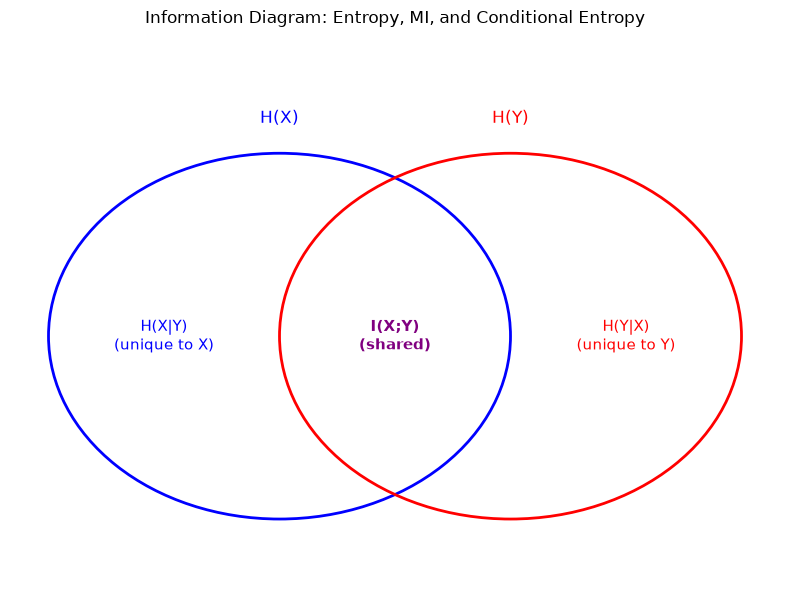

In [6]:
import numpy as np

# Perplexity for language models
def perplexity(log_probs):
    return np.exp(-np.mean(log_probs))

# Simulate language model predictions
# Good model: high probability for correct tokens
log_probs_good = np.log([0.8, 0.75, 0.9, 0.85, 0.7])
log_probs_bad = np.log([0.1, 0.05, 0.2, 0.15, 0.08])

print(f"Good model perplexity: {perplexity(log_probs_good):.3f}")
print(f"Bad model perplexity:  {perplexity(log_probs_bad):.3f}")
print("(Lower is better model is less 'surprised' by text)")

# Information Bottleneck intuition
print("\n=== Information Bottleneck ===")
print("Goal: Find representation Z that maximizes I(Z;Y) (useful for task)")
print("      while minimizing I(Z;X) (compressed, removes irrelevant info)")
print("This is the fundamental compression-prediction tradeoff in DL")

# Visualize information diagram (Venn diagram of entropy)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 6))
circle1 = plt.Circle((0.35, 0.5), 0.3, fill=False, color='blue', linewidth=2)
circle2 = plt.Circle((0.65, 0.5), 0.3, fill=False, color='red', linewidth=2)
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.text(0.2, 0.5, 'H(X|Y)\n(unique to X)', ha='center', va='center', fontsize=11, color='blue')
ax.text(0.8, 0.5, 'H(Y|X)\n(unique to Y)', ha='center', va='center', fontsize=11, color='red')
ax.text(0.5, 0.5, 'I(X;Y)\n(shared)', ha='center', va='center', fontsize=11, color='purple', fontweight='bold')
ax.text(0.35, 0.85, 'H(X)', ha='center', fontsize=12, color='blue')
ax.text(0.65, 0.85, 'H(Y)', ha='center', fontsize=12, color='red')
ax.set_xlim(0, 1)
ax.set_ylim(0.1, 1)
ax.set_title('Information Diagram: Entropy, MI, and Conditional Entropy', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## Additional Learning Resources

### Original Works
- **A Mathematical Theory of Communication Claude Shannon (1948)**: https://people.math.harvard.edu/~ctm/home/text/others/shannon/entropy/entropy.pdf
- **David MacKay Information Theory, Inference, and Learning Algorithms (free book)**: http://www.inference.org.uk/mackay/itila/

### Video Courses
- **StatQuest Entropy and Information Gain**: https://www.youtube.com/watch?v=YtebGVx-Fxw
- **Aurelien Geron Info Theory (15 min)**: https://www.youtube.com/watch?v=ErfnhcEV9O8
- **MIT 6.050J Information and Entropy**: https://ocw.mit.edu/courses/6-050j-information-and-entropy-spring-2008/

### Papers
- **Auto-Encoding Variational Bayes (VAE uses KL)**: https://arxiv.org/abs/1312.6114
- **Generative Adversarial Networks (GAN uses JSD)**: https://arxiv.org/abs/1406.2661
- **Wasserstein GAN (replaces JSD with Wasserstein)**: https://arxiv.org/abs/1701.07875
- **Representation Learning with Contrastive Predictive Coding (uses MI)**: https://arxiv.org/abs/1807.03748
- **Deep Learning and the Information Bottleneck Principle**: https://arxiv.org/abs/1503.02406

### Books
- **Elements of Information Theory Cover & Thomas**: https://www.wiley.com/en-us/Elements+of+Information+Theory-p-9780471241959
- **Deep Learning Book Ch 3 (covers cross-entropy)**: https://www.deeplearningbook.org/contents/prob.html